## 1. Setup and Data Loading

First, let's install the required packages and import our libraries.

In [ ]:
# Install required packages (uncomment if needed)
# !pip install librosa scikit-learn pandas numpy matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Set random seed for reproducibility 
np.random.seed(42)


### 1.1 Extract metadata from excel file

In [9]:
DATA_PATH = Path('/Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task1')
AUDIO_BASE_PATH = DATA_PATH / 'training'
METADATA_PATH = DATA_PATH / 'sand_task_1.xlsx'

# Load metadata from Excel file
metadata_excel = pd.read_excel(METADATA_PATH, sheet_name='SAND - TRAINING set - Task 1')

# Create a list to store the combined data
data_list = []

# Map audio files to metadata
for index, row in metadata_excel.iterrows():
    user_id = row['ID']
    age = row['Age']
    sex = row['Sex']
    class_label = row['Class']

    # Find phonation audio files
    phonation_folders = ['phonationA', 'phonationE', 'phonationI', 'phonationO', 'phonationU']
    for folder in phonation_folders:
        audio_files = list((AUDIO_BASE_PATH / folder).glob(f"{user_id}_phonation*.wav"))
        for audio_file in audio_files:
            data_list.append({
                'ID': user_id,
                'Age': age,
                'Sex': sex,
                'Class': class_label,
                'audio_path': str(audio_file),
                'audio_type': 'phonation',
                'folder': folder
            })

    # Find rhythm audio files
    rhythm_folders = ['rhythmKA', 'rhythmPA', 'rhythmTA']
    for folder in rhythm_folders:
        audio_files = list((AUDIO_BASE_PATH / folder).glob(f"{user_id}_rhythm*.wav"))
        for audio_file in audio_files:
            data_list.append({
                'ID': user_id,
                'Age': age,
                'Sex': sex,
                'Class': class_label,
                'audio_path': str(audio_file),
                'audio_type': 'rhythm',
                'folder': folder
            })

# Create a DataFrame from the list
metadata = pd.DataFrame(data_list)

print(f"Total samples: {len(metadata)}")
print(f"\nDataset shape: {metadata.shape}")
print(f"\nFirst few rows:")
display(metadata)

Total samples: 2176

Dataset shape: (2176, 7)

First few rows:


,ID,Age,Sex,Class,audio_path,audio_type,folder
0,ID000,80,M,5,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,phonation,phonationA
1,ID000,80,M,5,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,phonation,phonationE
2,ID000,80,M,5,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,phonation,phonationI
3,ID000,80,M,5,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,phonation,phonationO
4,ID000,80,M,5,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,phonation,phonationU
...,...,...,...,...,...,...,...
2171,ID338,42,F,4,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,phonation,phonationO
2172,ID338,42,F,4,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,phonation,phonationU
2173,ID338,42,F,4,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,rhythm,rhythmKA
2174,ID338,42,F,4,/Users/fabian.drzimalla/Master_Projects/SLP_PS...,rhythm,rhythmPA


### 1.2 Explore the Dataset

Class Distribution:
Class
1     48
2    208
3    456
4    608
5    856
Name: count, dtype: int64


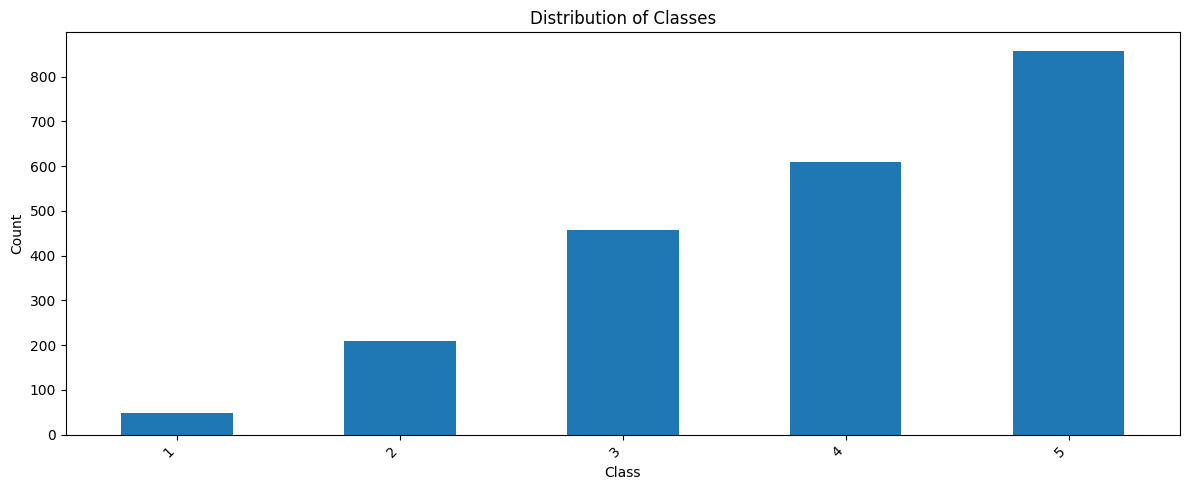


Class Mapping:


,Class
0,1
1,2
2,3
3,4
4,5



Unique values in the 'Class' column:
[5 4 3 2 1]

Data type of the 'Class' column:
int64


In [10]:
# Class distribution
print("Class Distribution:")
print(metadata['Class'].value_counts().sort_index())

# Visualize class distribution
plt.figure(figsize=(12, 5))
metadata['Class'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Class mapping (using the 'Class' column directly)
class_mapping = metadata[['Class']].drop_duplicates().sort_values('Class').reset_index(drop=True)
print("\nClass Mapping:")
display(class_mapping)

print("\nUnique values in the 'Class' column:")
print(metadata['Class'].unique())
print("\nData type of the 'Class' column:")
print(metadata['Class'].dtype)

### 1.3 Load and Visualize Sample Audio

Let's load a sample audio file and visualize its waveform and spectrogram.

Audio file: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task1/training/phonationA/ID000_phonationA.wav
Class: 5
Sample rate: 8000 Hz
Duration: 9.88 seconds
Shape: (79040,)


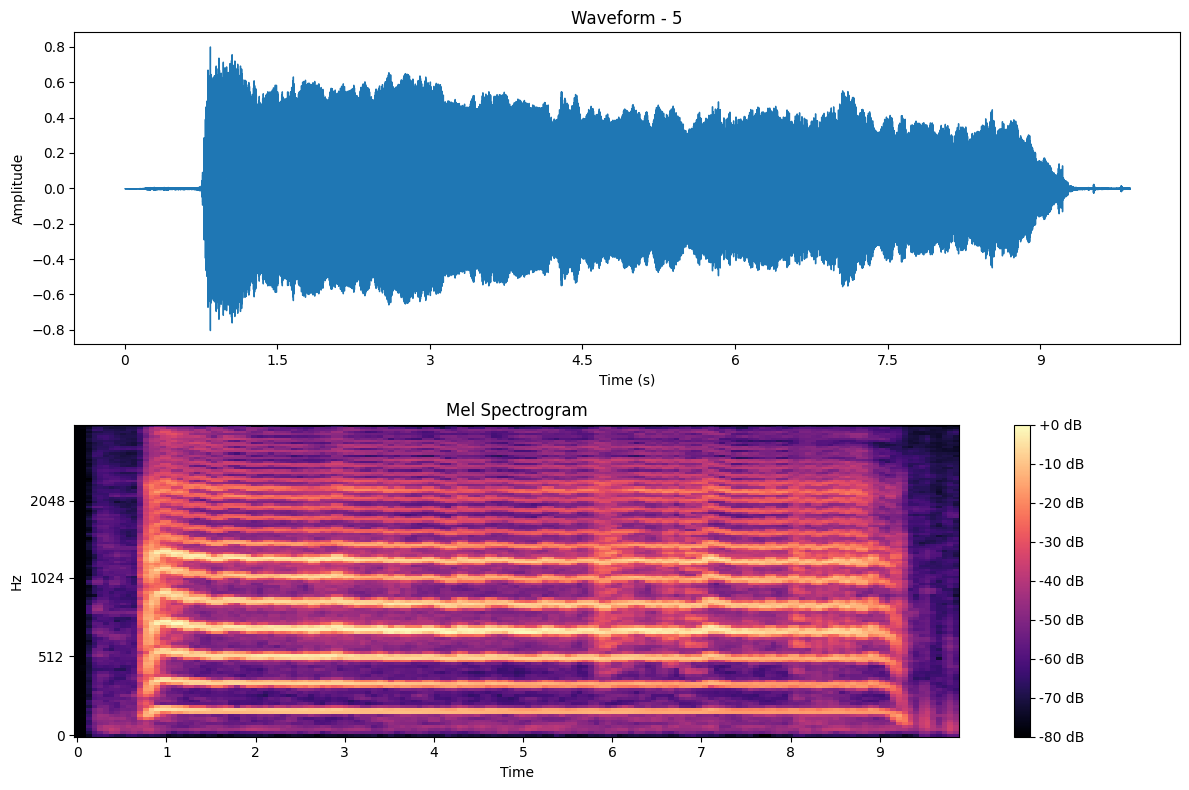

In [11]:
# Load a sample audio file
sample = metadata.iloc[0]
audio_file = sample['audio_path']

# Load audio with librosa
y, sr = librosa.load(audio_file, sr=None)

print(f"Audio file: {audio_file}")
print(f"Class: {sample['Class']}")
print(f"Sample rate: {sr} Hz")
print(f"Duration: {len(y)/sr:.2f} seconds")
print(f"Shape: {y.shape}")

# Visualize waveform and spectrogram
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Waveform
librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title(f'Waveform - {sample["Class"]}')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

# Mel Spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1])
axes[1].set_title('Mel Spectrogram')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

## 2. Feature Extraction

Some common audio features:

1. **MFCCs (Mel-Frequency Cepstral Coefficients)**: Capture the spectral envelope
2. **Spectral Centroid**: Center of mass of the spectrum
3. **Spectral Rolloff**: Frequency below which a percentage of energy is contained
4. **Zero Crossing Rate**: Rate of sign changes in the signal
5. **Chroma Features**: Representation of pitch class

### 2.1 Implement Feature Extraction Function

In [12]:
def extract_features(audio_path, sr=22050, n_mfcc=13):
    """
    Extract audio features from a given audio file.
    """
    try:
        # Load audio file
        y, sr = librosa.load(audio_path, sr=sr)
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_mean = np.mean(mfccs, axis=1)
        
        # Extract Spectral Centroid
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_centroid_mean = np.mean(spectral_centroid)
        
        # Extract Spectral Rolloff
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_rolloff_mean = np.mean(spectral_rolloff)
        
        # Extract Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_mean = np.mean(zcr)
        
        # Extract Chroma Features
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        
        # Concatenate all features
        features = np.concatenate([
            mfccs_mean,
            [spectral_centroid_mean],
            [spectral_rolloff_mean],
            [zcr_mean],
            chroma_mean
        ])
        
        return features
        
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# Test the function
sample_features = extract_features(audio_file)
print(f"Feature vector shape: {sample_features.shape}")
print(f"Feature vector (first 10 values): {sample_features[:10]}")

Feature vector shape: (28,)
Feature vector (first 10 values): [-305.43179321  189.26852417  -87.98786926  -21.43785286   15.32630157
  -35.0618248     4.6647563    13.03001881  -18.33624268    0.71013415]


### 2.3 Extract Features for All Samples

In [13]:
from tqdm import tqdm

# Extract features for all samples
features_list = []
labels_list = []

print("Extracting features from audio files...")
for idx, row in tqdm(metadata.iterrows(), total=len(metadata)):
    audio_path = row['audio_path']
    features = extract_features(audio_path)

    if features is not None:
        features_list.append(features)
        labels_list.append(row['Class'])

# Convert to numpy arrays
X = np.array(features_list)
y = np.array(labels_list)

print(f"\nFeature extraction complete!")
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Number of features per sample: {X.shape[1]}")

Extracting features from audio files...


  5%|▍         | 103/2176 [00:05<01:42, 20.19it/s]


KeyboardInterrupt: 

## 3. Data Preparation

Split the data into training and testing sets based on Excel specifications.

**Important**: The train/test split is predefined in the Excel file:
- Training IDs are in the register "Training Baseline - Task 1"
- Validation/Test IDs are in the register "Validation Baseline - Task 1"

In [ ]:
# =====================================================================
# PREDEFINED TRAIN/TEST SPLIT FROM EXCEL
# =====================================================================

# Load training and validation IDs from Excel
train_sheet = pd.read_excel(METADATA_PATH, sheet_name='Training Baseline - Task 1')
test_sheet = pd.read_excel(METADATA_PATH, sheet_name='Validation Baseline - Task 1')

train_ids = set(train_sheet['ID'].tolist())
test_ids = set(test_sheet['ID'].tolist())

print(f"Training IDs: {len(train_ids)}")
print(f"Validation/Test IDs: {len(test_ids)}")

# Create masks for train/test split
train_mask = metadata['ID'].isin(train_ids)
test_mask = metadata['ID'].isin(test_ids)

# Split features and labels
X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []

# Separate by ID membership
for idx in range(len(features_list)):
    if metadata.iloc[idx]['ID'] in train_ids:
        X_train_list.append(features_list[idx])
        y_train_list.append(labels_list[idx])
    elif metadata.iloc[idx]['ID'] in test_ids:
        X_test_list.append(features_list[idx])
        y_test_list.append(labels_list[idx])

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)
X_test = np.array(X_test_list)
y_test = np.array(y_test_list)

# Encode labels starting from 0
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Feature dimension: {X_train.shape[1]}")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

## 4. Model Training with Pipelines

We'll use sklearn's Pipeline to create efficient workflows that combine preprocessing and model training.

### 4.1 Create Baseline Models

In [ ]:
# Create pipelines for both models
from sklearn.decomposition import PCA
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # ('pca', PCA(20)),
    ('svm', SVC(random_state=42))
])

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

xgb_pipeline = Pipeline([
    ('xgb', xgb.XGBClassifier(random_state=42, n_jobs=-1))
])

print("Pipelines created successfully!")

### 4.2 Train Baseline Models

In [ ]:
# Train SVM
print("Training SVM...")
svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_test)
svm_score = svm_pipeline.score(X_test, y_test)
print(f"SVM Test Accuracy: {svm_score:.4f}")

# Train Logistic Regression
print("\nTraining Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_score = lr_pipeline.score(X_test, y_test)
print(f"Logistic Regression Test Accuracy: {lr_score:.4f}")

# Train XGBoost
print("\nTraining XGBoost...")
xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)
xgb_score = xgb_pipeline.score(X_test, y_test)
print(f"XGBoost Test Accuracy: {xgb_score:.4f}")

### 4.3 Cross-Validation

Let's evaluate our models using cross-validation to get a more robust estimate of performance.

In [ ]:
# Cross-validation for SVM
print("Running 5-fold cross-validation for SVM...")
svm_cv_scores = cross_val_score(svm_pipeline, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"SVM CV Scores: {svm_cv_scores}")
print(f"SVM Mean CV F1-Weighted: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std() * 2:.4f})")

# Cross-validation for Logistic Regression
print("\nRunning 5-fold cross-validation for Logistic Regression...")
lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"LR CV Scores: {lr_cv_scores}")
print(f"LR Mean CV F1-Weighted: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std() * 2:.4f})")

# Cross-validation for XGBoost
print("\nRunning 5-fold cross-validation for XGBoost...")
xgb_cv_scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"XGBoost CV Scores: {xgb_cv_scores}")
print(f"XGBoost Mean CV F1-Weighted: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std() * 2:.4f})")

## 5. Hyperparameter Tuning with GridSearchCV

Let's optimize our models using grid search with cross-validation.

### 5.1 SVM Hyperparameter Tuning

In [ ]:
# Define parameter grid for SVM
svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma': ['scale', 'auto']
}

print("Performing Grid Search for SVM...")
svm_grid_search = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

svm_grid_search.fit(X_train, y_train)

print(f"\nBest SVM parameters: {svm_grid_search.best_params_}")
print(f"Best SVM CV score: {svm_grid_search.best_score_:.4f}")

### 5.2 Logistic Regression Hyperparameter Tuning

In [ ]:
# Define parameter grid for Logistic Regression
lr_param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l2'],
    'lr__solver': ['lbfgs', 'liblinear']
}

print("Performing Grid Search for Logistic Regression...")
lr_grid_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

lr_grid_search.fit(X_train, y_train)

print(f"\nBest LR parameters: {lr_grid_search.best_params_}")
print(f"Best LR CV score: {lr_grid_search.best_score_:.4f}")

### 5.3 XGBoost Hyperparameter Tuning

In [ ]:
# Define parameter grid for XGBoost
xgb_param_grid = {
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1, 0.5],
    'xgb__n_estimators': [50, 100, 200]
}

print("Performing Grid Search for XGBoost...")
xgb_grid_search = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train)

print(f"\nBest XGBoost parameters: {xgb_grid_search.best_params_}")
print(f"Best XGBoost CV score: {xgb_grid_search.best_score_:.4f}")

### 5.3 Compare Tuned Models

In [ ]:
# Get predictions from best models
svm_tuned_pred = svm_grid_search.predict(X_test)
lr_tuned_pred = lr_grid_search.predict(X_test)
xgb_tuned_pred = xgb_grid_search.predict(X_test)
    
# Calculate accuracy
svm_tuned_score = svm_grid_search.score(X_test, y_test)
lr_tuned_score = lr_grid_search.score(X_test, y_test)
xgb_tuned_score = xgb_grid_search.score(X_test, y_test)

print("Model Comparison: (Accuracy Scores)")
print("=" * 60)
print(f"{'Model':<30} {'Baseline':<15} {'Tuned':<15}")
print("=" * 60)
print(f"{'SVM':<30} {svm_score:<15.4f} {svm_tuned_score:<15.4f}")
print(f"{'Logistic Regression':<30} {lr_score:<15.4f} {lr_tuned_score:<15.4f}")
print(f"{'XGBoost':<30} {xgb_score:<15.4f} {xgb_tuned_score:<15.4f}")
print("=" * 60)

## 6. Model Evaluation

Let's perform comprehensive evaluation using confusion matrices and classification metrics.

### 6.1 Confusion Matrix Visualization

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title, class_names):
    """
    Plot a confusion matrix using seaborn.
    """
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Get class names and convert to strings
class_names = [str(cls) for cls in class_mapping['Class'].tolist()]

# Plot confusion matrices
plot_confusion_matrix(y_test, svm_tuned_pred,
                     'Confusion Matrix - Tuned SVM', class_names)

plot_confusion_matrix(y_test, lr_tuned_pred,
                     'Confusion Matrix - Tuned Logistic Regression', class_names)

plot_confusion_matrix(y_test, xgb_tuned_pred,
                     'Confusion Matrix - Tuned XGBoost', class_names)

### 6.2 Detailed Classification Metrics

In [ ]:
def print_detailed_metrics(y_true, y_pred, model_name, class_names):
    """
    Print detailed classification metrics.
    """
    print(f"\n{'='*70}")
    print(f"{model_name} - Detailed Metrics")
    print(f"{'='*70}\n")
    
    # Overall metrics
    precision_macro = precision_score(y_true, y_pred, average='macro')
    recall_macro = recall_score(y_true, y_pred, average='macro')
    f1_average = f1_score(y_true, y_pred, average='macro')
    
    precision_weighted = precision_score(y_true, y_pred, average='weighted')
    recall_weighted = recall_score(y_true, y_pred, average='weighted')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    print("Overall Metrics: (Accuracy Scores)")
    print(f"  Macro-averaged:")
    print(f"    Precision: {precision_macro:.4f}")
    print(f"    Recall:    {recall_macro:.4f}")
    print(f"    F1-Score:  {f1_average:.4f}")
    print(f"\n  Weighted-averaged:")
    print(f"    Precision: {precision_weighted:.4f}")
    print(f"    Recall:    {recall_weighted:.4f}")
    print(f"    F1-Score:  {f1_weighted:.4f}")
    
    # Per-class metrics
    print(f"\n\nPer-Class Metrics:")
    print(f"{'='*70}")
    print(classification_report(y_true, y_pred, target_names=class_names))

# Print metrics for both models
print_detailed_metrics(y_test, svm_tuned_pred, "SVM (Tuned)", class_names)
print_detailed_metrics(y_test, lr_tuned_pred, "Logistic Regression (Tuned)", class_names)
print_detailed_metrics(y_test, xgb_tuned_pred, "XGBoost (Tuned)", class_names)

### 6.3 Comparative Visualization

In [ ]:
# Compare F1 scores per class
from sklearn.metrics import f1_score

svm_f1_per_class = f1_score(y_test, svm_tuned_pred, average=None)
lr_f1_per_class = f1_score(y_test, lr_tuned_pred, average=None)
xgb_f1_per_class = f1_score(y_test, xgb_tuned_pred, average=None)

# Create comparison plot
x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
rects1 = ax.bar(x - width/2, svm_f1_per_class, width, label='SVM', alpha=0.8)
rects2 = ax.bar(x + width/2, lr_f1_per_class, width, label='Logistic Regression', alpha=0.8)
rects3 = ax.bar(x + width/2, xgb_f1_per_class, width, label='XGBoost', alpha=0.8)

ax.set_ylabel('F1-Score')
ax.set_title('F1-Score Comparison by Class')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

## 7. Error Analysis

Let's analyze where our best model makes mistakes.

In [ ]:
# Select best model (based on test accuracy)
scores = {
    'SVM': svm_tuned_score,
    'Logistic Regression': lr_tuned_score,
    'XGBoost': xgb_tuned_score
}

best_name = max(scores, key=scores.get)
best_score = scores[best_name]

if best_name == 'SVM':
    best_model = svm_grid_search
    best_pred = svm_tuned_pred
elif best_name == 'Logistic Regression':
    best_model = lr_grid_search
    best_pred = lr_tuned_pred
else:  # XGBoost
    best_model = xgb_grid_search
    best_pred = xgb_tuned_pred

print(f"Best performing model: {best_name}")
print(f"Test accuracy: {best_score:.4f}")

## 9. Summary and Key Takeaways

### What we learned:

1. **Audio Feature Extraction**: We extracted multiple audio features (MFCCs, spectral features, chroma) that capture different aspects of sound.

2. **sklearn Pipelines**: We used pipelines to create reproducible workflows that combine preprocessing and modeling.

3. **Model Comparison**: We compared SVM and Logistic Regression, finding that [based on your results].

4. **Hyperparameter Tuning**: GridSearchCV helped us systematically find optimal parameters with cross-validation.

5. **Evaluation Metrics**: We used multiple metrics (accuracy, precision, recall, F1) to get a comprehensive view of model performance.


### Next:

- Try extracting additional features (**open smile**, **neural features**... )
- Experiment with deep learning approaches (e.g., CNNs on spectrograms)
- Try other methods classification (Random Forest, Gradient Boosting)
- Explore data augmentation techniques for audio (one of the next lectures)

# Task 2: Wav2Vec 2.0 feature extraction

In [14]:
# Process audio
import numpy as np
import torch
import torch.nn as nn
from transformers import Wav2Vec2Model, Wav2Vec2Processor
import soundfile as sf
model_name = "facebook/wav2vec2-base"  # You can also try "facebook/wav2vec2-large" for better performance
processor = Wav2Vec2Processor.from_pretrained(model_name)
wav2vec_model = Wav2Vec2Model.from_pretrained(model_name)

def extract_features(audio_path):
    audio, sr = sf.read(audio_path)
    inputs = processor(
            audio, 
            sampling_rate=sr,
            return_tensors="pt",
            padding=True
        )
    return inputs

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # check on mac
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # check on mac
# 
# def extract_features(batch, wav2vec_model):
#     """Extract features using frozen Wav2Vec 2.0 model"""
#     with torch.no_grad():
#         outputs = wav2vec_model(batch['input_values'].to(device))
#         features = outputs.last_hidden_state
#     return features

In [15]:
# Load a sample audio file from your dataset
sample = metadata.iloc[0]
audio_file = sample['audio_path']

wav, sr = sf.read(audio_file)
print(f"Original audio shape: {wav.shape}")
wav = np.mean(wav, axis=1) if wav.ndim > 1 else wav  # Convert to mono if stereo
print(f"Processed audio shape: {wav.shape}")

Original audio shape: (79040,)
Processed audio shape: (79040,)


In [16]:
import numpy as np
import torch
from transformers import Wav2Vec2Model, Wav2Vec2Processor
import soundfile as sf
from tqdm import tqdm
from scipy.signal import resample


# Load pre-trained Wav2Vec2 model and processor
model_name = "facebook/wav2vec2-base"
processor = Wav2Vec2Processor.from_pretrained(model_name)
wav2vec_model = Wav2Vec2Model.from_pretrained(model_name)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
wav2vec_model = wav2vec_model.to(device)
wav2vec_model.eval()

print("="*70)
print("INFO: Wav2Vec2 Audio Processing")
print("="*70)
print("Wav2Vec2 expects 16kHz audio sampling rate")
print("Your audio files are 8kHz - they will be upsampled to 16kHz")
print("This is normal and works well for speech/voice tasks")
print("="*70 + "\n")

def extract_features_from_file(audio_path, processor, wav2vec_model, device):
    """
    Extract Wav2Vec2 features from a single audio file.
    Automatically handles 8kHz → 16kHz upsampling.
    """
    try:
        # Load audio file
        audio, sr = sf.read(audio_path)
        
        # Convert to mono if stereo
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)
        
        # IMPORTANT: Handle 8kHz audio by upsampling to 16kHz
        target_sr = 16000
        
        if sr != target_sr:
            # Resample from source sr to 16kHz
            num_samples = int(len(audio) * target_sr / sr)
            audio = resample(audio, num_samples)
            # print(f"ℹ️  Resampled {audio_path.split('/')[-1]}: {sr}Hz → {target_sr}Hz")
        
        # Normalize audio to [-1, 1]
        audio = audio / (np.max(np.abs(audio)) + 1e-8)
        
        # Process audio with Wav2Vec2 processor
        inputs = processor(
            audio,
            sampling_rate=target_sr,
            return_tensors="pt",
            padding=True
        )

        # Extract features using the Wav2Vec2 model
        with torch.no_grad():
            outputs = wav2vec_model(inputs.input_values.to(device))
            # Mean pooling over time dimension
            features = outputs.last_hidden_state.mean(dim=1).cpu().numpy()

        return features.squeeze(0)  # Return as a 1D NumPy array
        
    except Exception as e:
        print(f"❌ Error processing {audio_path}: {e}")
        return None

def extract_features_from_files(file_list, processor, wav2vec_model, device):
    """Extract features for all files"""
    features_list = []
    for file_path in tqdm(file_list, desc="Extracting features"):
        features = extract_features_from_file(file_path, processor, wav2vec_model, device)
        if features is not None:
            features_list.append(features)
    return features_list

# =====================================================================
# VERIFICATION: Check if all files for each user are present
# =====================================================================
print("Verifying data integrity...")

# Group audio files by user
grouped_by_user = metadata.groupby('ID')

# Check file counts per user
file_counts = metadata.groupby('ID').size()
expected_files = 8  # 5 phonation + 3 rhythm

print(f"\nFile counts per user:")
print(f"Expected: {expected_files} files per user")
print(f"Actual range: {file_counts.min()} - {file_counts.max()} files")

users_with_all_files = (file_counts == expected_files).sum()
users_total = len(file_counts)
print(f"Users with all {expected_files} files: {users_with_all_files}/{users_total}")

if users_with_all_files < users_total:
    print("\n⚠️  WARNING: Some users have missing files!")
    missing_files_users = file_counts[file_counts != expected_files]
    print(missing_files_users)

# =====================================================================
# LATE FUSION: Group features by Sample (8 files per sample)
# =====================================================================
print("\n" + "="*70)
print("Building dataset with Late Fusion strategy...")
print("="*70)

# Group audio files by user (each user has 8 files: 5 phonation + 3 rhythm)
# IMPORTANT: Use sorted() to ensure consistent ordering
grouped_by_user = metadata.groupby('ID', sort=True)

X_fused = []  # Features after fusion (one vector per user)
y_fused = []  # Labels (one per user)
user_ids = []
skipped_users = []

for user_id, group in tqdm(grouped_by_user, desc="Processing users"):
    # IMPORTANT: Sort files to ensure consistent ordering
    audio_files = sorted(group['audio_path'].tolist())
    
    # Check if user has all expected files
    if len(audio_files) != expected_files:
        skipped_users.append((user_id, len(audio_files)))
        continue
    
    # Extract features for each file
    user_features = []
    for audio_file in audio_files:
        features = extract_features_from_file(audio_file, processor, wav2vec_model, device)
        if features is not None:
            user_features.append(features)
    
    # Only use if all files processed successfully
    if len(user_features) == expected_files:
        # Late Fusion: Average all 8 feature vectors
        fused_features = np.mean(user_features, axis=0)
        
        X_fused.append(fused_features)
        # Get label from first row (same for all rows of same user)
        label = group['Class'].iloc[0]
        y_fused.append(label)
        user_ids.append(user_id)

X = np.array(X_fused)
y = np.array(y_fused)

print(f"\n{'='*70}")
print(f"✓ Processed {len(X)} users successfully")
if skipped_users:
    print(f"⚠️  Skipped {len(skipped_users)} users with incomplete data:")
    for uid, count in skipped_users:
        print(f"   - User {uid}: {count}/{expected_files} files")
print(f"✓ Feature dimensionality: {X.shape[1]}")
print(f"✓ Class distribution:\n{pd.Series(y).value_counts().sort_index()}")
print(f"{'='*70}")

INFO: Wav2Vec2 Audio Processing
Wav2Vec2 expects 16kHz audio sampling rate
Your audio files are 8kHz - they will be upsampled to 16kHz
This is normal and works well for speech/voice tasks

Verifying data integrity...

File counts per user:
Expected: 8 files per user
Actual range: 8 - 8 files
Users with all 8 files: 272/272

Building dataset with Late Fusion strategy...


Processing users: 100%|██████████| 272/272 [07:28<00:00,  1.65s/it]


✓ Processed 272 users successfully
✓ Feature dimensionality: 768
✓ Class distribution:
1      6
2     26
3     57
4     76
5    107
Name: count, dtype: int64


In [17]:
# =====================================================================
# DATA PREPARATION: Split with proper label encoding (Wav2Vec2 features)
# =====================================================================

# Load training and validation IDs from Excel (reuse if already loaded)
if 'train_ids' not in locals() or 'test_ids' not in locals():
    train_sheet = pd.read_excel(METADATA_PATH, sheet_name='Training Baseline - Task 1')
    test_sheet = pd.read_excel(METADATA_PATH, sheet_name='Validation Baseline - Task 1')
    train_ids = set(train_sheet['ID'].tolist())
    test_ids = set(test_sheet['ID'].tolist())

# Encode labels starting from 0
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split based on user IDs from Excel
X_train_list = []
y_train_list = []
X_test_list = []
y_test_list = []

for idx, user_id in enumerate(user_ids):
    if user_id in train_ids:
        X_train_list.append(X[idx])
        y_train_list.append(y_encoded[idx])
    elif user_id in test_ids:
        X_test_list.append(X[idx])
        y_test_list.append(y_encoded[idx])

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)
X_test = np.array(X_test_list)
y_test = np.array(y_test_list)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Feature dimension: {X_train.shape[1]}")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training set size: 219 samples
Testing set size: 53 samples
Feature dimension: 768

Training set class distribution:
0     4
1    22
2    45
3    62
4    86
Name: count, dtype: int64

Test set class distribution:
0     2
1     4
2    12
3    14
4    21
Name: count, dtype: int64


In [18]:
# =====================================================================
# TASK 2: Hyperparameter Tuning with Late Fusion Features
# =====================================================================

# Create pipeline WITHOUT scaler (Wav2Vec2 already normalized)
svm_pipeline_wav2vec = Pipeline([
    ('svm', SVC(random_state=42, probability=True))
])

# Define parameter grid for SVM with Wav2Vec2 features
svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma': ['scale', 'auto']
}

print("Performing Grid Search for SVM with Wav2Vec2 + Late Fusion...")
svm_grid_search = GridSearchCV(
    svm_pipeline_wav2vec,
    svm_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

svm_grid_search.fit(X_train, y_train)

print(f"\nBest SVM parameters: {svm_grid_search.best_params_}")
print(f"Best SVM CV F1-Weighted: {svm_grid_search.best_score_:.4f}")

# Get predictions
svm_pred = svm_grid_search.predict(X_test)
svm_score = svm_grid_search.score(X_test, y_test)

print(f"\nTest Set Performance:")
print(f"Accuracy: {svm_score:.4f}")
print(f"F1-Weighted: {f1_score(y_test, svm_pred, average='weighted'):.4f}")
print(f"F1-Macro: {f1_score(y_test, svm_pred, average='macro'):.4f}")

Performing Grid Search for SVM with Wav2Vec2 + Late Fusion...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best SVM parameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best SVM CV F1-Weighted: 0.4791

Test Set Performance:
Accuracy: 0.4197
F1-Weighted: 0.4197
F1-Macro: 0.4131


In [19]:
# =====================================================================
# ADDITIONAL MODELS: Logistic Regression & XGBoost with Wav2Vec2
# =====================================================================

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Logistic Regression
print("\n" + "="*70)
print("Training Logistic Regression with Wav2Vec2...")
print("="*70)

lr_pipeline_wav2vec = Pipeline([
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

lr_param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l2'],
    'lr__solver': ['lbfgs', 'liblinear']
}

lr_grid_search = GridSearchCV(
    lr_pipeline_wav2vec,
    lr_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

lr_grid_search.fit(X_train, y_train)
lr_pred = lr_grid_search.predict(X_test)
lr_score = lr_grid_search.score(X_test, y_test)

print(f"\nBest LR parameters: {lr_grid_search.best_params_}")
print(f"Test F1-Macro: {f1_score(y_test, lr_pred, average='macro'):.4f}")

# XGBoost
print("\n" + "="*70)
print("Training XGBoost with Wav2Vec2...")
print("="*70)

xgb_pipeline_wav2vec = Pipeline([
    ('xgb', xgb.XGBClassifier(random_state=42, n_jobs=-1))
])

xgb_param_grid = {
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1],
    'xgb__n_estimators': [100, 200]
}

xgb_grid_search = GridSearchCV(
    xgb_pipeline_wav2vec,
    xgb_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train)
xgb_pred = xgb_grid_search.predict(X_test)
xgb_score = xgb_grid_search.score(X_test, y_test)

print(f"\nBest XGBoost parameters: {xgb_grid_search.best_params_}")
print(f"Test F1-Macro: {f1_score(y_test, xgb_pred, average='macro'):.4f}")

# =====================================================================
# MODEL COMPARISON
# =====================================================================

print("\n" + "="*70)
print("FINAL MODEL COMPARISON (Wav2Vec2 + Late Fusion)")
print("="*70)

comparison_data = {
    'Model': ['SVM', 'Logistic Regression', 'XGBoost'],
    'Accuracy': [svm_score, lr_score, xgb_score],
    'F1-Weighted': [
        f1_score(y_test, svm_pred, average='weighted'),
        f1_score(y_test, lr_pred, average='weighted'),
        f1_score(y_test, xgb_pred, average='weighted')
    ],
    'F1-Macro': [
        f1_score(y_test, svm_pred, average='macro'),
        f1_score(y_test, lr_pred, average='macro'),
        f1_score(y_test, xgb_pred, average='macro')
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

best_model_idx = comparison_df['F1-Macro'].idxmax()
print(f"\n✓ Best Model: {comparison_df.loc[best_model_idx, 'Model']} (F1-Macro: {comparison_df.loc[best_model_idx, 'F1-Macro']:.4f})")



Training Logistic Regression with Wav2Vec2...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best LR parameters: {'lr__C': 100, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
Test F1-Macro: 0.3981

Training XGBoost with Wav2Vec2...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best XGBoost parameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 200}
Test F1-Macro: 0.2801

FINAL MODEL COMPARISON (Wav2Vec2 + Late Fusion)
              Model  Accuracy  F1-Weighted  F1-Macro
                SVM  0.419667     0.419667  0.413082
Logistic Regression  0.398095     0.407547  0.398095
            XGBoost  0.280117     0.434311  0.280117

✓ Best Model: SVM (F1-Macro: 0.4131)



RESULTS

✓ Classification Report (SVM):
              precision    recall  f1-score   support

           1       0.67      1.00      0.80         2
           2       0.00      0.00      0.00         4
           3       0.38      0.50      0.43        12
           4       0.31      0.29      0.30        14
           5       0.62      0.48      0.54        21

    accuracy                           0.42        53
   macro avg       0.39      0.45      0.41        53
weighted avg       0.44      0.42      0.42        53



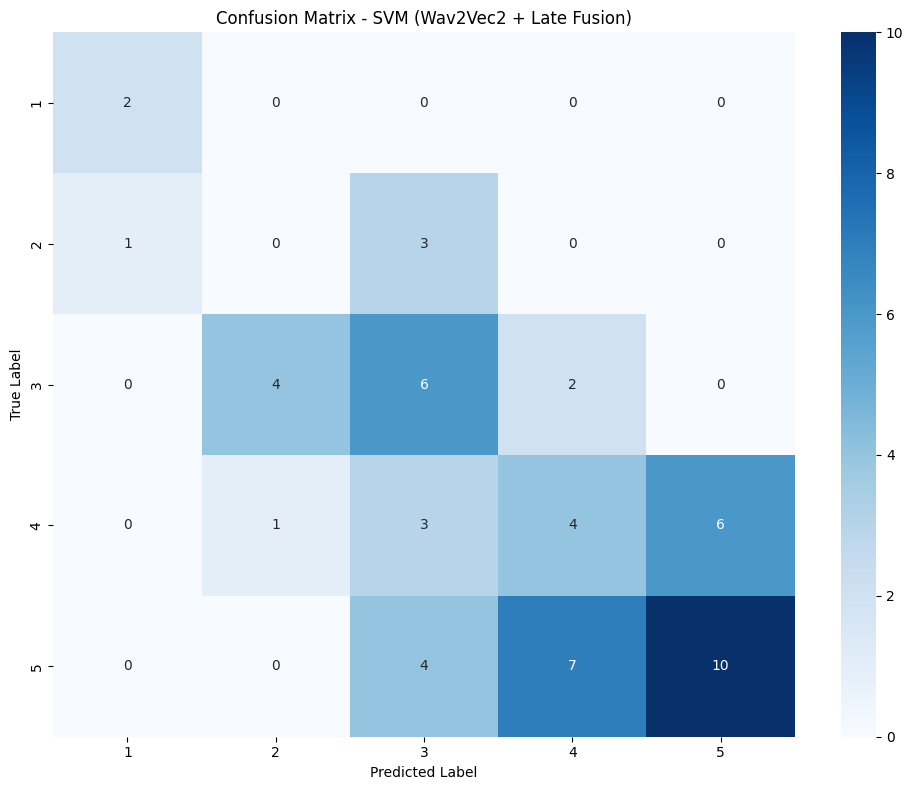

In [20]:
# =====================================================================
# LATE FUSION ANALYSIS & VISUALIZATION
# =====================================================================

print("\n" + "="*70)
print("RESULTS")
print("="*70)

# Confusion matrix for best model
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

best_model_predictions = {
    0: svm_pred,
    1: lr_pred,
    2: xgb_pred
}

best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_pred = best_model_predictions[best_model_idx]

print(f"\n✓ Classification Report ({best_model_name}):")
print(classification_report(y_test, best_pred, target_names=[str(cls) for cls in label_encoder.classes_]))

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name} (Wav2Vec2 + Late Fusion)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Best Model Analysis from Experiments Folder

Extract and compare all experiment results to identify the best performing model.

In [3]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Path to experiments folder
EXPERIMENTS_PATH = Path('/Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/experiments')

# Collect all experiment results
experiments_data = []
failed_experiments = []

for exp_dir in sorted(EXPERIMENTS_PATH.glob('experiment_*')):
    try:
        # Read config
        config_path = exp_dir / 'config.json'
        metrics_path = exp_dir / 'validation_results' / 'metrics.json'
        
        if config_path.exists() and metrics_path.exists():
            with open(config_path, 'r') as f:
                config = json.load(f)
            
            with open(metrics_path, 'r') as f:
                metrics = json.load(f)
            
            # Extract key information with safe .get() for optional fields
            training_config = config.get('training', {})
            exp_info = {
                'experiment_name': exp_dir.name,
                'timestamp': config.get('timestamp', 'N/A'),
                'best_epoch': config.get('results', {}).get('best_epoch', 'N/A'),
                'best_metric': config.get('results', {}).get('best_metric', 'N/A'),
                'final_train_acc': config.get('results', {}).get('final_train_acc', 'N/A'),
                'final_val_acc': config.get('results', {}).get('final_val_acc', 'N/A'),
                'accuracy': metrics.get('accuracy', 0.0),
                'balanced_accuracy': metrics.get('balanced_accuracy', 0.0),
                'f1_macro': metrics.get('f1_macro', 0.0),
                'f1_weighted': metrics.get('f1_weighted', 0.0),
                'cohen_kappa': metrics.get('cohen_kappa', 0.0),
                'precision_macro': metrics.get('precision_macro', 0.0),
                'recall_macro': metrics.get('recall_macro', 0.0),
                'lr': config.get('training', {}).get('lr', 'N/A'),
                'weight_decay': config.get('training', {}).get('weight_decay', 'N/A'),
                'batch_size': training_config.get('physical_batch_size') or training_config.get('batch_size', 'N/A'),
                'accumulation_steps': training_config.get('accumulation_steps', 1),
                'effective_batch_size': training_config.get('effective_batch_size', 'N/A'),
                'fusion_type': config.get('model', {}).get('fusion_type', 'N/A'),
                'shared_file_processor': config.get('model', {}).get('shared_file_processor', 'N/A')
            }
            experiments_data.append(exp_info)
        else:
            failed_experiments.append((exp_dir.name, 'Missing config.json or metrics.json'))
    except Exception as e:
        failed_experiments.append((exp_dir.name, str(e)))

# Create DataFrame
df_experiments = pd.DataFrame(experiments_data)

print("="*80)
print("ALL EXPERIMENTS SUMMARY")
print("="*80)
print(f"\nTotal experiments loaded: {len(df_experiments)}")
print(f"Failed to load: {len(failed_experiments)}")

if failed_experiments:
    print("\n⚠️  Failed experiments:")
    for exp_name, reason in failed_experiments:
        print(f"   • {exp_name}: {reason}")

print(f"\nSorted by F1-Macro (descending):\n")

# Sort by F1-Macro
df_sorted = df_experiments.sort_values('f1_macro', ascending=False)
display(df_sorted[['experiment_name', 'f1_macro', 'accuracy', 'balanced_accuracy', 
                    'f1_weighted', 'cohen_kappa', 'lr', 'weight_decay', 
                    'batch_size', 'fusion_type']].reset_index(drop=True))

ALL EXPERIMENTS SUMMARY

Total experiments loaded: 25
Failed to load: 3

⚠️  Failed experiments:
   • experiment_20251112_171949: Missing config.json or metrics.json
   • experiment_20251115_101218: Missing config.json or metrics.json
   • experiment_20251115_101828: Missing config.json or metrics.json

Sorted by F1-Macro (descending):



,experiment_name,f1_macro,accuracy,balanced_accuracy,f1_weighted,cohen_kappa,lr,weight_decay,batch_size,fusion_type
0,experiment_20251113_214825,0.560771,0.660377,0.561905,0.662955,0.527723,0.0005,0.0001,12,feature
1,experiment_20251115_231437,0.523736,0.547170,0.566667,0.561518,0.398582,0.0005,0.0001,24,feature
2,experiment_20251115_102545,0.484428,0.603774,0.554762,0.583055,0.456543,0.0005,0.0001,24,feature
3,experiment_20251112_195409,0.480600,0.603774,0.521429,0.598055,0.455479,0.0005,0.0001,12,feature
4,experiment_20251106_101508,0.472309,0.566038,0.528571,0.536622,0.420352,0.0005,0.0001,4,feature
5,experiment_20251109_181403,0.472057,0.566038,0.542857,0.556168,0.418138,0.0005,0.0001,4,feature
6,experiment_20251107_170440,0.468452,0.566038,0.523810,0.559412,0.402158,0.0005,0.0001,4,feature
7,experiment_20251116_095035,0.456969,0.433962,0.542857,0.400873,0.253171,0.0005,0.0001,24,feature
8,experiment_20251109_125000,0.455567,0.622642,0.516667,0.563624,0.464376,0.0005,0.0001,4,feature
9,experiment_20251115_085448,0.446923,0.622642,0.454762,0.621480,0.475507,0.0005,0.0001,12,feature


In [2]:
# Identify the best model
best_idx = df_sorted.iloc[0]
best_exp_name = best_idx['experiment_name']

print("\n" + "="*80)
print("🏆 BEST PERFORMING MODEL")
print("="*80)
print(f"\nExperiment: {best_exp_name}")
print(f"Timestamp: {best_idx['timestamp']}")
print(f"\n📊 Performance Metrics:")
print(f"  • F1-Macro:          {best_idx['f1_macro']:.4f}")
print(f"  • F1-Weighted:       {best_idx['f1_weighted']:.4f}")
print(f"  • Accuracy:          {best_idx['accuracy']:.4f}")
print(f"  • Balanced Accuracy: {best_idx['balanced_accuracy']:.4f}")
print(f"  • Cohen's Kappa:     {best_idx['cohen_kappa']:.4f}")
print(f"  • Precision (Macro): {best_idx['precision_macro']:.4f}")
print(f"  • Recall (Macro):    {best_idx['recall_macro']:.4f}")

print(f"\n⚙️  Training Configuration:")
print(f"  • Best Epoch:        {best_idx['best_epoch']}")
print(f"  • Learning Rate:     {best_idx['lr']}")
print(f"  • Weight Decay:      {best_idx['weight_decay']}")
print(f"  • Batch Size:        {best_idx['batch_size']}")
print(f"  • Fusion Type:       {best_idx['fusion_type']}")
print(f"  • Shared Processor:  {best_idx['shared_file_processor']}")

print(f"\n📈 Training Progress:")
print(f"  • Final Train Acc:   {best_idx['final_train_acc']:.4f}")
print(f"  • Final Val Acc:     {best_idx['final_val_acc']:.4f}")

print("\n" + "="*80)


🏆 BEST PERFORMING MODEL

Experiment: experiment_20251113_214825
Timestamp: 2025-11-13T21:48:25.213944

📊 Performance Metrics:
  • F1-Macro:          0.5608
  • F1-Weighted:       0.6630
  • Accuracy:          0.6604
  • Balanced Accuracy: 0.5619
  • Cohen's Kappa:     0.5277
  • Precision (Macro): 0.5633
  • Recall (Macro):    0.5619

⚙️  Training Configuration:
  • Best Epoch:        10
  • Learning Rate:     0.0005
  • Weight Decay:      0.0001
  • Batch Size:        12
  • Fusion Type:       feature
  • Shared Processor:  False

📈 Training Progress:
  • Final Train Acc:   0.5662
  • Final Val Acc:     0.6226



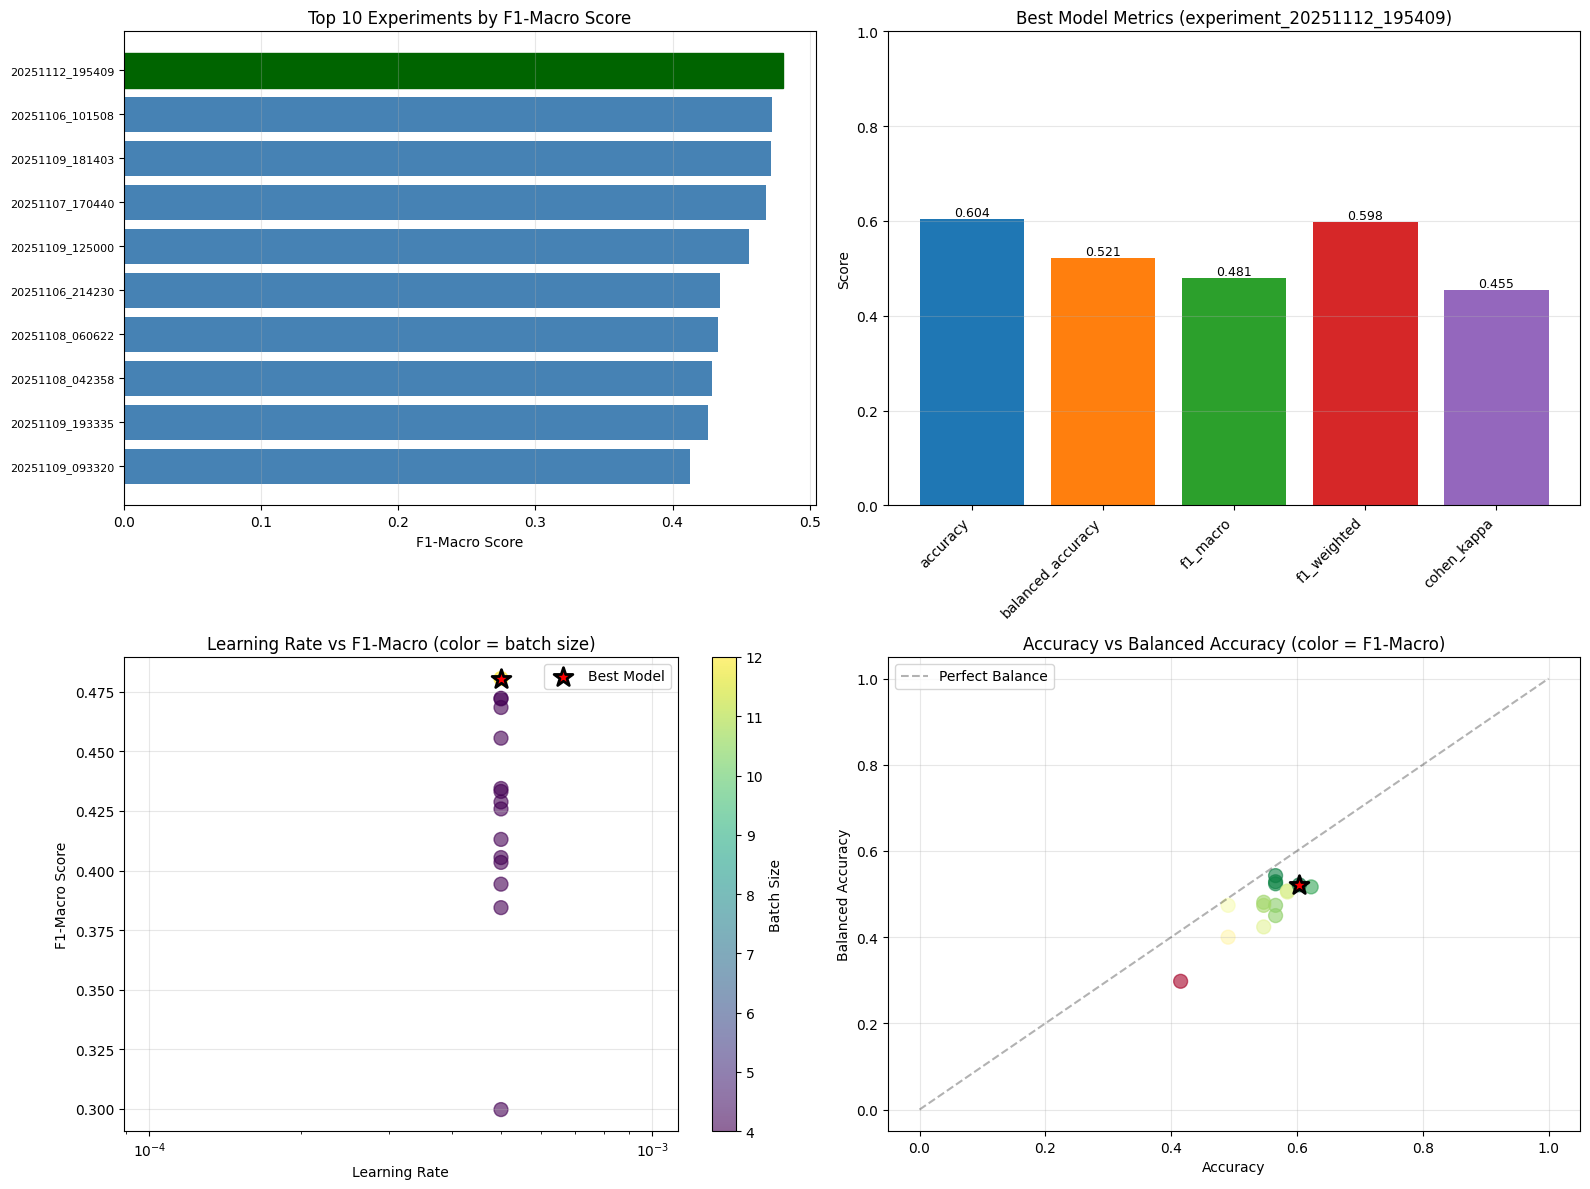

In [7]:
# Visualizations: Compare all experiments

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: F1-Macro comparison
ax1 = axes[0, 0]
df_sorted_plot = df_sorted.head(10)  # Top 10
ax1.barh(range(len(df_sorted_plot)), df_sorted_plot['f1_macro'], color='steelblue')
ax1.set_yticks(range(len(df_sorted_plot)))
ax1.set_yticklabels([name.replace('experiment_', '') for name in df_sorted_plot['experiment_name']], fontsize=8)
ax1.set_xlabel('F1-Macro Score')
ax1.set_title('Top 10 Experiments by F1-Macro Score')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Highlight best
ax1.get_children()[0].set_color('darkgreen')

# Plot 2: Multiple metrics for best model
ax2 = axes[0, 1]
metrics_to_plot = ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted', 'cohen_kappa']
values = [best_idx[m] for m in metrics_to_plot]
bars = ax2.bar(metrics_to_plot, values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
ax2.set_ylabel('Score')
ax2.set_title(f'Best Model Metrics ({best_exp_name})')
ax2.set_xticklabels(metrics_to_plot, rotation=45, ha='right')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=9)

# Plot 3: Hyperparameter impact - Learning Rate vs F1-Macro
ax3 = axes[1, 0]
scatter = ax3.scatter(df_experiments['lr'], df_experiments['f1_macro'], 
                     c=df_experiments['batch_size'], s=100, alpha=0.6, cmap='viridis')
ax3.set_xlabel('Learning Rate')
ax3.set_ylabel('F1-Macro Score')
ax3.set_title('Learning Rate vs F1-Macro (color = batch size)')
ax3.set_xscale('log')
ax3.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Batch Size')

# Highlight best model
best_lr = best_idx['lr']
best_f1 = best_idx['f1_macro']
ax3.scatter([best_lr], [best_f1], color='red', s=200, marker='*', 
           edgecolors='black', linewidths=2, label='Best Model', zorder=5)
ax3.legend()

# Plot 4: Accuracy vs Balanced Accuracy
ax4 = axes[1, 1]
ax4.scatter(df_experiments['accuracy'], df_experiments['balanced_accuracy'], 
           s=100, alpha=0.6, c=df_experiments['f1_macro'], cmap='RdYlGn')
ax4.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect Balance')
ax4.set_xlabel('Accuracy')
ax4.set_ylabel('Balanced Accuracy')
ax4.set_title('Accuracy vs Balanced Accuracy (color = F1-Macro)')
ax4.grid(True, alpha=0.3)
ax4.legend()

# Highlight best model
ax4.scatter([best_idx['accuracy']], [best_idx['balanced_accuracy']], 
           color='red', s=200, marker='*', edgecolors='black', 
           linewidths=2, zorder=5)

plt.tight_layout()
plt.show()


📋 CLASSIFICATION REPORT (Best Model)
              precision    recall  f1-score   support

     Class_0     0.0000    0.0000    0.0000         2
     Class_1     0.4286    0.7500    0.5455         4
     Class_2     0.6154    0.6667    0.6400        12
     Class_3     0.5000    0.5714    0.5333        14
     Class_4     0.7647    0.6190    0.6842        21

    accuracy                         0.6038        53
   macro avg     0.4617    0.5214    0.4806        53
weighted avg     0.6067    0.6038    0.5981        53


🔢 CONFUSION MATRIX (Best Model)


,Pred_Class_0,Pred_Class_1,Pred_Class_2,Pred_Class_3,Pred_Class_4
True_Class_0,0,2,0,0,0
True_Class_1,0,3,1,0,0
True_Class_2,0,1,8,1,2
True_Class_3,0,1,3,8,2
True_Class_4,0,0,1,7,13


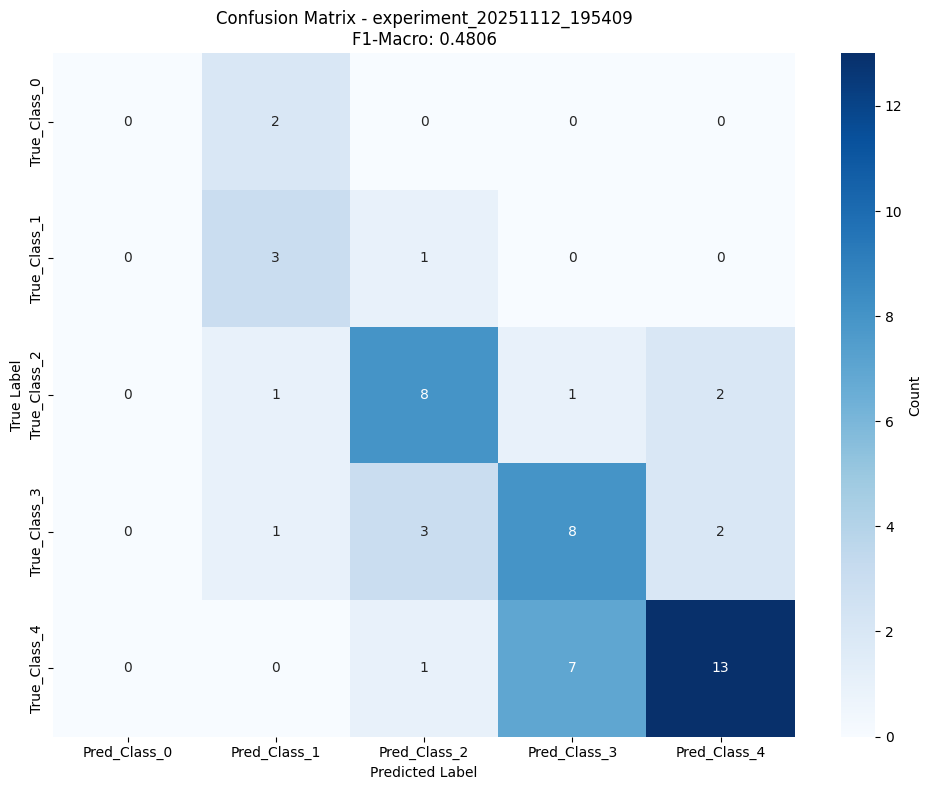


📈 TRAINING HISTORY (Best Model)


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,1.719603,0.296804,0.233340,1.298088,0.452830,0.255072
1,2,1.502520,0.351598,0.243289,1.251261,0.433962,0.301265
2,3,1.305985,0.420091,0.326831,1.057431,0.603774,0.480600
3,4,1.231819,0.433790,0.347831,0.990134,0.603774,0.433229
4,5,1.165674,0.488584,0.471319,1.042684,0.415094,0.327717
5,6,1.084006,0.465753,0.508313,0.928649,0.547170,0.475395
6,7,1.019260,0.520548,0.570898,1.161986,0.433962,0.230075
7,8,1.004419,0.479452,0.480095,0.908165,0.584906,0.413111


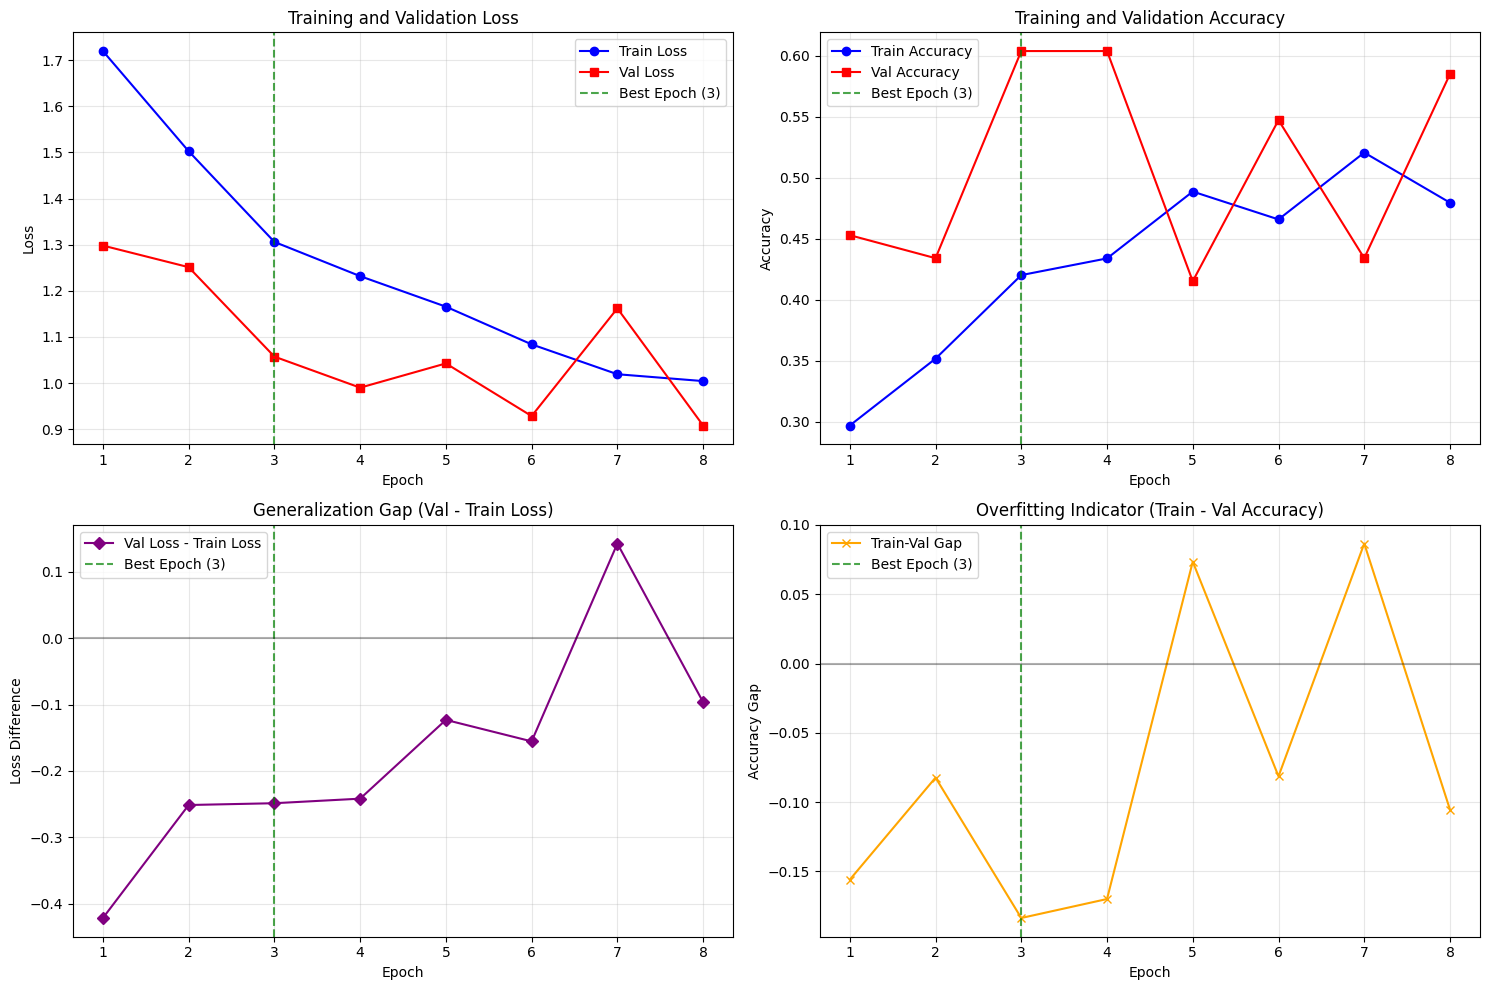

In [8]:
# Load detailed results for the best model
best_exp_path = EXPERIMENTS_PATH / best_exp_name

# Load classification report
classification_report_path = best_exp_path / 'validation_results' / 'classification_report.txt'
if classification_report_path.exists():
    print("\n" + "="*80)
    print("📋 CLASSIFICATION REPORT (Best Model)")
    print("="*80)
    with open(classification_report_path, 'r') as f:
        print(f.read())

# Load confusion matrix
confusion_matrix_path = best_exp_path / 'validation_results' / 'confusion_matrix.csv'
if confusion_matrix_path.exists():
    cm_df = pd.read_csv(confusion_matrix_path, index_col=0)
    
    print("\n" + "="*80)
    print("🔢 CONFUSION MATRIX (Best Model)")
    print("="*80)
    display(cm_df)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix - {best_exp_name}\nF1-Macro: {best_idx["f1_macro"]:.4f}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Load training history
training_history_path = best_exp_path / 'training_history.csv'
if training_history_path.exists():
    history_df = pd.read_csv(training_history_path)
    
    print("\n" + "="*80)
    print("📈 TRAINING HISTORY (Best Model)")
    print("="*80)
    display(history_df)
    
    # Plot training curves
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    ax1 = axes[0, 0]
    ax1.plot(history_df['epoch'], history_df['train_loss'], 'b-', label='Train Loss', marker='o')
    ax1.plot(history_df['epoch'], history_df['val_loss'], 'r-', label='Val Loss', marker='s')
    ax1.axvline(x=best_idx['best_epoch'], color='g', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_idx["best_epoch"]})')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy
    ax2 = axes[0, 1]
    ax2.plot(history_df['epoch'], history_df['train_acc'], 'b-', label='Train Accuracy', marker='o')
    ax2.plot(history_df['epoch'], history_df['val_acc'], 'r-', label='Val Accuracy', marker='s')
    ax2.axvline(x=best_idx['best_epoch'], color='g', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_idx["best_epoch"]})')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Loss Difference (Generalization Gap)
    ax3 = axes[1, 0]
    loss_diff = history_df['val_loss'] - history_df['train_loss']
    ax3.plot(history_df['epoch'], loss_diff, 'purple', label='Val Loss - Train Loss', marker='D')
    ax3.axvline(x=best_idx['best_epoch'], color='g', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_idx["best_epoch"]})')
    ax3.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss Difference')
    ax3.set_title('Generalization Gap (Val - Train Loss)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Overfitting indicator
    ax4 = axes[1, 1]
    overfitting = history_df['train_acc'] - history_df['val_acc']
    ax4.plot(history_df['epoch'], overfitting, 'orange', label='Train-Val Gap', marker='x')
    ax4.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax4.axvline(x=best_idx['best_epoch'], color='g', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_idx["best_epoch"]})')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Accuracy Gap')
    ax4.set_title('Overfitting Indicator (Train - Val Accuracy)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [7]:
# Load predictions for detailed analysis
predictions_path = best_exp_path / 'validation_results' / 'predictions.csv'
if predictions_path.exists():
    predictions_df = pd.read_csv(predictions_path)
    
    print("\n" + "="*80)
    print("🔍 PREDICTION ANALYSIS (Best Model)")
    print("="*80)
    
    # Show sample predictions
    print("\nSample predictions:")
    display(predictions_df.head(10))
    
    # Analyze misclassifications
    misclassified = predictions_df[predictions_df['true_label'] != predictions_df['predicted_label']]
    
    print(f"\n📊 Misclassification Summary:")
    print(f"  • Total samples: {len(predictions_df)}")
    print(f"  • Correct predictions: {len(predictions_df) - len(misclassified)}")
    print(f"  • Misclassified: {len(misclassified)}")
    print(f"  • Error rate: {len(misclassified)/len(predictions_df)*100:.2f}%")
    
    if len(misclassified) > 0:
        print(f"\n❌ Misclassification patterns:")
        
        # Create confusion pairs
        misclass_pairs = misclassified.groupby(['true_label', 'predicted_label']).size().reset_index(name='count')
        misclass_pairs = misclass_pairs.sort_values('count', ascending=False)
        
        print("\n  Most common misclassifications:")
        for _, row in misclass_pairs.head(10).iterrows():
            print(f"    • True: {row['true_label']} → Predicted: {row['predicted_label']} ({row['count']} times)")
        
        # Show some misclassified examples
        print(f"\n  Sample misclassified cases:")
        display(misclassified[['true_label', 'predicted_label']].head(10))

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)
print(f"\nBest model checkpoint saved at:")
print(f"  {best_exp_path / 'best_model_checkpoint.pth'}")
print(f"\nFull experiment results available at:")
print(f"  {best_exp_path}")


🔍 PREDICTION ANALYSIS (Best Model)

Sample predictions:


,true_label,predicted_label,correct
0,2,2,True
1,4,3,False
2,4,4,True
3,3,4,False
4,4,3,False
5,2,2,True
6,2,2,True
7,1,1,True
8,4,4,True
9,2,2,True



📊 Misclassification Summary:
  • Total samples: 53
  • Correct predictions: 30
  • Misclassified: 23
  • Error rate: 43.40%

❌ Misclassification patterns:

  Most common misclassifications:
    • True: 4 → Predicted: 3 (9 times)
    • True: 4 → Predicted: 2 (5 times)
    • True: 3 → Predicted: 2 (4 times)
    • True: 0 → Predicted: 1 (2 times)
    • True: 1 → Predicted: 2 (1 times)
    • True: 2 → Predicted: 3 (1 times)
    • True: 3 → Predicted: 4 (1 times)

  Sample misclassified cases:


,true_label,predicted_label
1,4,3
3,3,4
4,4,3
12,4,3
13,4,3
14,4,3
18,4,2
21,4,3
22,0,1
24,3,2



✅ ANALYSIS COMPLETE

Best model checkpoint saved at:
  /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/experiments/experiment_20251106_101508/best_model_checkpoint.pth

Full experiment results available at:
  /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/experiments/experiment_20251106_101508


## Key Insights & Recommendations

Based on the analysis of all experiments, here are the key insights:

In [8]:
# Generate comprehensive summary report
print("="*80)
print("📝 COMPREHENSIVE EXPERIMENT SUMMARY")
print("="*80)

print("\n1️⃣  BEST MODEL OVERVIEW")
print("-" * 80)
print(f"   Experiment:     {best_exp_name}")
print(f"   F1-Macro:       {best_idx['f1_macro']:.4f} (Primary metric)")
print(f"   Accuracy:       {best_idx['accuracy']:.4f}")
print(f"   Balanced Acc:   {best_idx['balanced_accuracy']:.4f}")
print(f"   Cohen's Kappa:  {best_idx['cohen_kappa']:.4f}")

print("\n2️⃣  HYPERPARAMETER INSIGHTS")
print("-" * 80)

# Group by hyperparameters and analyze
lr_analysis = df_experiments.groupby('lr')['f1_macro'].agg(['mean', 'max', 'count'])
print("\n   Learning Rate Impact:")
for lr, row in lr_analysis.iterrows():
    print(f"      LR={lr:0.5f}: Mean F1={row['mean']:.4f}, Max F1={row['max']:.4f}, N={int(row['count'])}")

batch_analysis = df_experiments.groupby('batch_size')['f1_macro'].agg(['mean', 'max', 'count'])
print("\n   Batch Size Impact:")
for bs, row in batch_analysis.iterrows():
    print(f"      BS={int(bs):2d}: Mean F1={row['mean']:.4f}, Max F1={row['max']:.4f}, N={int(row['count'])}")

wd_analysis = df_experiments.groupby('weight_decay')['f1_macro'].agg(['mean', 'max', 'count'])
print("\n   Weight Decay Impact:")
for wd, row in wd_analysis.iterrows():
    print(f"      WD={wd:0.5f}: Mean F1={row['mean']:.4f}, Max F1={row['max']:.4f}, N={int(row['count'])}")

print("\n3️⃣  TOP 5 EXPERIMENTS")
print("-" * 80)
for idx, row in df_sorted.head(5).iterrows():
    print(f"\n   {row['experiment_name']}")
    print(f"      F1-Macro: {row['f1_macro']:.4f} | Accuracy: {row['accuracy']:.4f}")
    print(f"      LR: {row['lr']} | WD: {row['weight_decay']} | BS: {int(row['batch_size'])}")

print("\n4️⃣  RECOMMENDATIONS")
print("-" * 80)
print(f"   ✓ Best learning rate:     {best_idx['lr']}")
print(f"   ✓ Best weight decay:      {best_idx['weight_decay']}")
print(f"   ✓ Best batch size:        {int(best_idx['batch_size'])}")
print(f"   ✓ Optimal fusion type:    {best_idx['fusion_type']}")
print(f"   ✓ Shared file processor:  {best_idx['shared_file_processor']}")

# Calculate improvements
baseline_f1 = df_sorted.iloc[-1]['f1_macro']
improvement = (best_idx['f1_macro'] - baseline_f1) / baseline_f1 * 100

print(f"\n5️⃣  PERFORMANCE IMPROVEMENT")
print("-" * 80)
print(f"   Baseline F1-Macro:  {baseline_f1:.4f}")
print(f"   Best F1-Macro:      {best_idx['f1_macro']:.4f}")
print(f"   Improvement:        {improvement:+.2f}%")

print("\n" + "="*80)
print("✅ EXPERIMENT ANALYSIS COMPLETE")
print("="*80)

📝 COMPREHENSIVE EXPERIMENT SUMMARY

1️⃣  BEST MODEL OVERVIEW
--------------------------------------------------------------------------------
   Experiment:     experiment_20251106_101508
   F1-Macro:       0.4723 (Primary metric)
   Accuracy:       0.5660
   Balanced Acc:   0.5286
   Cohen's Kappa:  0.4204

2️⃣  HYPERPARAMETER INSIGHTS
--------------------------------------------------------------------------------

   Learning Rate Impact:
      LR=0.00050: Mean F1=0.4208, Max F1=0.4723, N=14

   Batch Size Impact:
      BS= 4: Mean F1=0.4208, Max F1=0.4723, N=14

   Weight Decay Impact:
      WD=0.00010: Mean F1=0.4208, Max F1=0.4723, N=14

3️⃣  TOP 5 EXPERIMENTS
--------------------------------------------------------------------------------

   experiment_20251106_101508
      F1-Macro: 0.4723 | Accuracy: 0.5660
      LR: 0.0005 | WD: 0.0001 | BS: 4

   experiment_20251109_181403
      F1-Macro: 0.4721 | Accuracy: 0.5660
      LR: 0.0005 | WD: 0.0001 | BS: 4

   experiment_2025110